In [2]:
from google.colab import files
uploaded = files.upload()

Saving cs-training.csv to cs-training.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cs-training.csv')
print("Shape:", df.shape)
df.head()

Shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Missing values aur basic info dekho
print("=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Variable Distribution ===")
print(df['SeriousDlqin2yrs'].value_counts())

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-n

In [5]:
# Missing values fix
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)

# Unnamed column drop
df.drop('Unnamed: 0', axis=1, inplace=True)

# Verify
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

New shape: (150000, 11)


/tmp/ipykernel_8881/1521511452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
/tmp/ipykernel_8881/1521511452.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [6]:
# Feature Engineering
df['DebtToIncome'] = df['DebtRatio'] * df['MonthlyIncome']
df['LatePaymentTotal'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                           df['NumberOfTimes90DaysLate'] +
                           df['NumberOfTime60-89DaysPastDueNotWorse'])

# X and y seperate
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale k
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Train size:", X_train.shape)
print(" Test size:", X_test.shape)

 Train size: (120000, 12)
 Test size: (30000, 12)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Model 1: Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("✅ Done!")

# Model 2: Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("✅ Done!")

# Model 3: Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("✅ Done!")

Training Logistic Regression...
✅ Done!
Training Decision Tree...
✅ Done!
Training Random Forest...
✅ Done!


In [8]:
# Evaluation function
def evaluate_model(name, y_test, y_pred, model, X_test_data):
    print(f"\n{'='*45}")
    print(f"📊 {name}")
    print('='*45)
    print(classification_report(y_test, y_pred))
    y_prob = model.predict_proba(X_test_data)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {auc:.4f}")
    return auc

# evaluate
auc_lr = evaluate_model("Logistic Regression", y_test, lr_pred, lr, X_test_scaled)
auc_dt = evaluate_model("Decision Tree", y_test, dt_pred, dt, X_test)
auc_rf = evaluate_model("Random Forest", y_test, rf_pred, rf, X_test)

# Final comparison
print("\n Model Comparison:")
import pandas as pd
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf]
})
print(results.sort_values('ROC-AUC', ascending=False))


📊 Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.05      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.53     30000
weighted avg       0.91      0.93      0.91     30000

ROC-AUC Score: 0.7149

📊 Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.60      0.15      0.24      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000

ROC-AUC Score: 0.8482

📊 Random Forest
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.18      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.75    

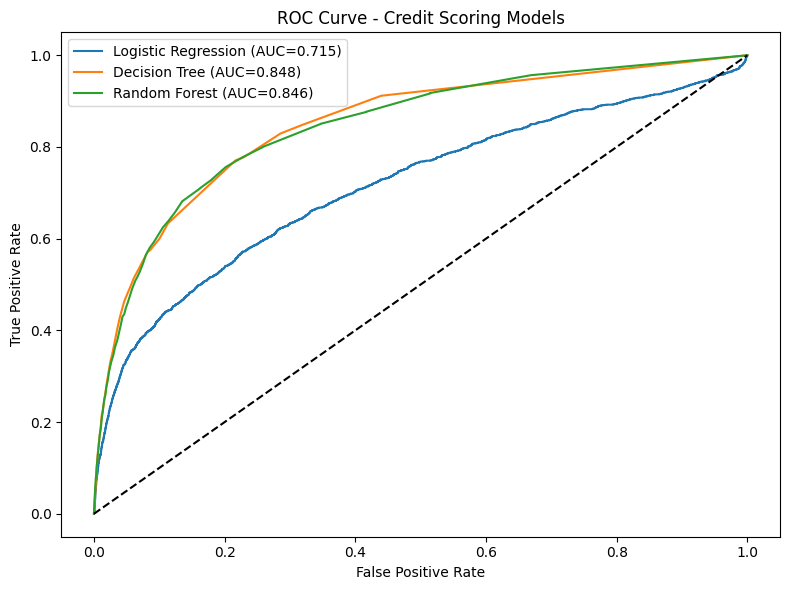

 Plot saved!


In [9]:
# ROC Curve plot
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model, X_t in [
    ("Logistic Regression", lr, X_test_scaled),
    ("Decision Tree", dt, X_test),
    ("Random Forest", rf, X_test)
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_t)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Scoring Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()
print(" Plot saved!")